# Hospital Bed Simulation


## 1. Imports and parameters

In [41]:
import numpy as np
import pandas as pd
import heapq
import matplotlib.pyplot as plt

T = 365              # simulation horizon in days
DAY_GRID = np.arange(T)

BASE_SEED = 1


## 2. Arrival rates and LOS distributions

In [22]:
def lambda1(t):
    """Arrival rate for type 1 regular epidemic patients."""
    t = np.asarray(t)
    return np.maximum(0.0, -(1.0 / 3650.0) * t**2 + 0.1 * t)


def lambda2(t):
    """Arrival rate for type 2 intensive epidemic patients."""
    return 0.2 * lambda1(t)


def lambda3(t):
    """Arrival rate for type 3 other patients."""
    return 6.0 + 0.0 * np.asarray(t)


# Mean LOS values from the project description
MEAN_LOS = {
    1: 8.0,
    2: 12.0,
    3: 10.0,
}

# Lognormal parameters used in the project
SIGMA2_LOGNORMAL = np.log(2.0)
SIGMA_LOGNORMAL = np.sqrt(SIGMA2_LOGNORMAL)

MU_LOGNORMAL = {
    1: np.log(4.0 * np.sqrt(2.0)),
    2: np.log(6.0 * np.sqrt(2.0)),
    3: np.log(5.0 * np.sqrt(2.0)),
}


def sample_los(patient_type, n, los_dist, rng):
    """Sample n length-of-stay values for one patient type."""
    if los_dist == "lognormal":
        return rng.lognormal(
            mean=MU_LOGNORMAL[patient_type],
            sigma=SIGMA_LOGNORMAL,
            size=n
        )
    elif los_dist == "exponential":
        return rng.exponential(
            scale=MEAN_LOS[patient_type],
            size=n
        )
    else:
        raise ValueError("los_dist must be 'lognormal' or 'exponential'")


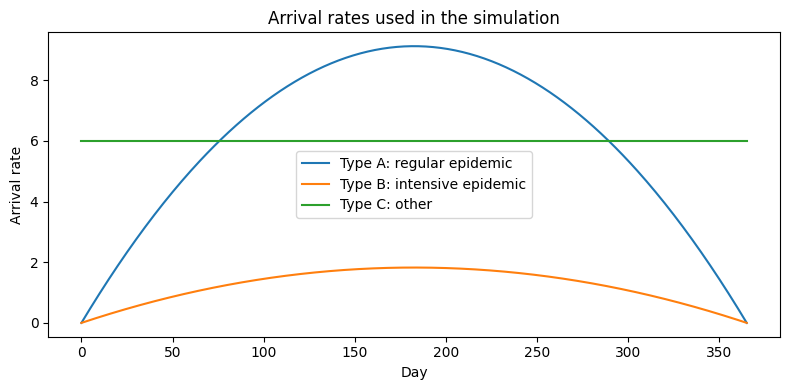

In [23]:
# Simple plot of the arrival rates
t_plot = np.linspace(0, T, 366)

plt.figure(figsize=(8, 4))
plt.plot(t_plot, lambda1(t_plot), label="Type A: regular epidemic")
plt.plot(t_plot, lambda2(t_plot), label="Type B: intensive epidemic")
plt.plot(t_plot, lambda3(t_plot), label="Type C: other")
plt.xlabel("Day")
plt.ylabel("Arrival rate")
plt.title("Arrival rates used in the simulation")
plt.legend()
plt.tight_layout()
plt.show()


## 3. Generate arrivals

For each day `d`, we approximate the non-homogeneous Poisson process by assuming the rate is constant during that day and equal to the midpoint value `lambda(d + 0.5)`. If `k` arrivals occur on a day, we place them uniformly in the interval `[d, d+1)`.


In [ ]:
def generate_arrival_events(rng, los_dist="lognormal"):
    
    events = []

    for d in range(T):
        # Midpoint arrival rates for this day
        rates = {
            1: float(lambda1(d + 0.5)),
            2: float(lambda2(d + 0.5)),
            3: float(lambda3(d + 0.5)),
        }

        for patient_type in [1, 2, 3]:
            n_arrivals = rng.poisson(rates[patient_type])

            if n_arrivals == 0:
                continue

            arrival_times = d + rng.random(n_arrivals)
            los_values = sample_los(patient_type, n_arrivals, los_dist, rng)

            for t, los in zip(arrival_times, los_values):
                events.append((t, patient_type, los))

    events.sort(key=lambda x: x[0])
    return events


## 4. One-year discrete-event simulation

Admission rules:

- Type 1 patients try Ward A. If Ward A is full, they are relocated.
- Type 2 patients try Ward B. If Ward B is full, they overflow to Ward A. If Ward A is also full, they are relocated.
- Type 3 patients try Ward C. If Ward C is full, they are relocated.



In [ ]:
def simulate_one_year(NA, NB, NC, los_dist="lognormal", seed=BASE_SEED, return_trace=False):
    
    rng = np.random.default_rng(seed)
    events = generate_arrival_events(rng, los_dist=los_dist)

    capacities = np.array([NA, NB, NC], dtype=int)
    occ = np.array([0, 0, 0], dtype=int)

    # Departure event list: (departure_time, ward_index)
    departures = []

    # Statistical accumulators
    n_arrivals = np.array([0, 0, 0], dtype=int)
    full_on_arrival = np.array([0, 0, 0], dtype=int)
    relocated = np.array([0, 0, 0], dtype=int)
    area = np.array([0.0, 0.0, 0.0])

    last_time = 0.0
    trace = [(0.0, 0, 0, 0)]

    def update_area(new_time):
        nonlocal last_time, area
        new_time = min(new_time, T)
        dt = new_time - last_time
        if dt > 0:
            area += occ * dt
            last_time = new_time

    def admit(patient_type, ward_index, time, los):
        """Admit patient to a ward and schedule departure if it occurs before T."""
        occ[ward_index] += 1
        departure_time = time + los
        if departure_time <= T:
            heapq.heappush(departures, (departure_time, ward_index))

    for time, patient_type, los in events:
        # Process all departures before the next arrival
        while departures and departures[0][0] <= time:
            dep_time, ward_index = heapq.heappop(departures)
            update_area(dep_time)
            occ[ward_index] -= 1
            if return_trace:
                trace.append((dep_time, occ[0], occ[1], occ[2]))

        update_area(time)

        i = patient_type - 1
        n_arrivals[i] += 1

        if patient_type == 1:
            # Type 1: Ward A only
            if occ[0] < NA:
                admit(patient_type, 0, time, los)
            else:
                full_on_arrival[0] += 1
                relocated[0] += 1

        elif patient_type == 2:
            # Type 2: Ward B first, then overflow to Ward A
            if occ[1] < NB:
                admit(patient_type, 1, time, los)
            else:
                full_on_arrival[1] += 1
                if occ[0] < NA:
                    admit(patient_type, 0, time, los)
                else:
                    relocated[1] += 1

        else:
            # Type 3: Ward C only
            if occ[2] < NC:
                admit(patient_type, 2, time, los)
            else:
                full_on_arrival[2] += 1
                relocated[2] += 1

        if return_trace:
            trace.append((time, occ[0], occ[1], occ[2]))

    # Process departures after the last arrival, but only up to the end of the year
    while departures and departures[0][0] <= T:
        dep_time, ward_index = heapq.heappop(departures)
        update_area(dep_time)
        occ[ward_index] -= 1
        if return_trace:
            trace.append((dep_time, occ[0], occ[1], occ[2]))

    update_area(T)

    # Avoid division by zero if a ward has zero beds
    utilisation = np.divide(
        area,
        capacities * T,
        out=np.zeros(3, dtype=float),
        where=capacities > 0
    )

    prob_full = np.divide(
        full_on_arrival,
        n_arrivals,
        out=np.zeros(3, dtype=float),
        where=n_arrivals > 0
    )

    prob_relocated = np.divide(
        relocated,
        n_arrivals,
        out=np.zeros(3, dtype=float),
        where=n_arrivals > 0
    )

    result = {
        "arrivals": n_arrivals,
        "full_on_arrival": full_on_arrival,
        "relocated": relocated,
        "prob_full": prob_full,
        "prob_relocated": prob_relocated,
        "utilisation": utilisation,
        "total_relocated": int(relocated.sum()),
    }

    if return_trace:
        return result, pd.DataFrame(trace, columns=["time", "occ_A", "occ_B", "occ_C"])

    return result


## 5. Helper functions for repeated replications



In [26]:
def mean_ci(x):
    """Mean and approximate 95% confidence interval."""
    x = np.asarray(x, dtype=float)
    mean = x.mean()
    se = x.std(ddof=1) / np.sqrt(len(x))
    return mean, mean - 1.96 * se, mean + 1.96 * se


def run_replications(NA, NB, NC, n_rep=100, los_dist="lognormal", seed=BASE_SEED):
    """Run independent replications using seeds seed, seed+1, seed+2, ..."""
    results = []
    for r in range(n_rep):
        results.append(
            simulate_one_year(
                NA, NB, NC,
                los_dist=los_dist,
                seed=seed + r
            )
        )
    return results


def summarize_results(results):
    """Create summary tables from a list of replication results."""
    patient_names = ["Type A", "Type B", "Type C"]
    ward_names = ["Ward A", "Ward B", "Ward C"]

    rows = []
    for i in range(3):
        p_full = [res["prob_full"][i] for res in results]
        p_reloc = [res["prob_relocated"][i] for res in results]
        n_reloc = [res["relocated"][i] for res in results]

        rows.append({
            "patient_type": patient_names[i],
            "P(primary ward full)": mean_ci(p_full)[0],
            "P(relocated)": mean_ci(p_reloc)[0],
            "mean relocated/year": mean_ci(n_reloc)[0],
            "relocated CI low": mean_ci(n_reloc)[1],
            "relocated CI high": mean_ci(n_reloc)[2],
        })

    total_relocated = [res["total_relocated"] for res in results]
    rows.append({
        "patient_type": "Total",
        "P(primary ward full)": np.nan,
        "P(relocated)": np.nan,
        "mean relocated/year": mean_ci(total_relocated)[0],
        "relocated CI low": mean_ci(total_relocated)[1],
        "relocated CI high": mean_ci(total_relocated)[2],
    })

    patient_table = pd.DataFrame(rows)

    util_rows = []
    for i in range(3):
        util = [res["utilisation"][i] for res in results]
        util_rows.append({
            "ward": ward_names[i],
            "mean utilisation": mean_ci(util)[0],
            "utilisation CI low": mean_ci(util)[1],
            "utilisation CI high": mean_ci(util)[2],
        })

    utilisation_table = pd.DataFrame(util_rows)
    return patient_table, utilisation_table


## 6. Baseline allocation


In [27]:
NA0, NB0, NC0 = 30, 5, 40
N_REP = 100

baseline_results = run_replications(
    NA0, NB0, NC0,
    n_rep=N_REP,
    los_dist="lognormal",
    seed=BASE_SEED
)

patient_table, utilisation_table = summarize_results(baseline_results)

display(patient_table)
display(utilisation_table)


,patient_type,P(primary ward full),P(relocated),mean relocated/year,relocated CI low,relocated CI high
0,Type A,0.548752,0.548752,1223.39,1213.481557,1233.298443
1,Type B,0.706697,0.416553,185.74,182.031546,189.448454
2,Type C,0.350623,0.350623,769.15,759.293959,779.006041
3,Total,NaN,NaN,2178.28,2162.862967,2193.697033


,ward,mean utilisation,utilisation CI low,utilisation CI high
0,Ward A,0.868063,0.866499,0.869626
1,Ward B,0.848727,0.844894,0.852561
2,Ward C,0.949554,0.948631,0.950476


## 7. Plot one simulated year




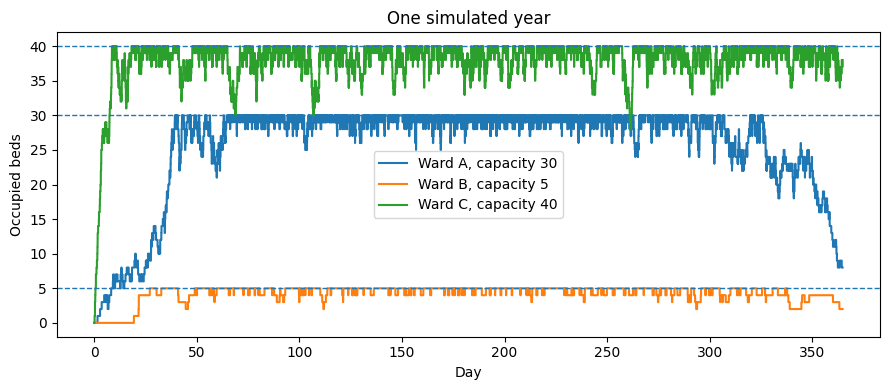

In [28]:
one_result, trace = simulate_one_year(
    NA0, NB0, NC0,
    los_dist="lognormal",
    seed=BASE_SEED,
    return_trace=True
)

plt.figure(figsize=(9, 4))
plt.step(trace["time"], trace["occ_A"], where="post", label=f"Ward A, capacity {NA0}")
plt.step(trace["time"], trace["occ_B"], where="post", label=f"Ward B, capacity {NB0}")
plt.step(trace["time"], trace["occ_C"], where="post", label=f"Ward C, capacity {NC0}")
plt.axhline(NA0, linestyle="--", linewidth=1)
plt.axhline(NB0, linestyle="--", linewidth=1)
plt.axhline(NC0, linestyle="--", linewidth=1)
plt.xlabel("Day")
plt.ylabel("Occupied beds")
plt.title("One simulated year")
plt.legend()
plt.tight_layout()
plt.show()


## 8. Sensitivity to bed distribution

We search over bed allocations in steps of 5 beds. The objective is the mean total number of relocated patients per year.


In [ ]:
def estimate_total_relocated(NA, NB, NC, n_rep=50, los_dist="lognormal", seed=BASE_SEED):

    results = run_replications(
        NA, NB, NC,
        n_rep=n_rep,
        los_dist=los_dist,
        seed=seed
    )
    totals = [res["total_relocated"] for res in results]
    return mean_ci(totals)


def grid_search_beds(total_beds=75, step=5, n_rep=50, los_dist="lognormal", seed=BASE_SEED, min_B=0):
   
    rows = []

    for NA in range(0, total_beds + 1, step):
        for NB in range(min_B, total_beds - NA + 1, step):
            NC = total_beds - NA - NB

            if NC < 0:
                continue

            mean, lo, hi = estimate_total_relocated(
                NA, NB, NC,
                n_rep=n_rep,
                los_dist=los_dist,
                seed=seed
            )

            rows.append({
                "NA": NA,
                "NB": NB,
                "NC": NC,
                "mean total relocated": mean,
                "CI low": lo,
                "CI high": hi,
            })

    return pd.DataFrame(rows).sort_values("mean total relocated").reset_index(drop=True)


In [30]:
grid_75 = grid_search_beds(
    total_beds=75,
    step=5,
    n_rep=50,
    los_dist="lognormal",
    seed=BASE_SEED,
    min_B=0
)

grid_75.head(10)


,NA,NB,NC,mean total relocated,CI low,CI high
0,35,0,40,2145.40,2124.572065,2166.227935
1,30,0,45,2147.94,2127.108345,2168.771655
2,40,0,35,2151.90,2130.955008,2172.844992
3,30,5,40,2173.16,2152.647760,2193.672240
4,45,0,30,2173.36,2152.766937,2193.953063
5,25,0,50,2174.58,2154.220931,2194.939069
6,35,5,35,2177.80,2156.595365,2199.004635
7,25,5,45,2184.74,2163.929100,2205.550900
8,40,5,30,2194.22,2173.231480,2215.208520
9,50,0,25,2207.68,2187.233063,2228.126937


### Heatmap of relocations by bed distribution


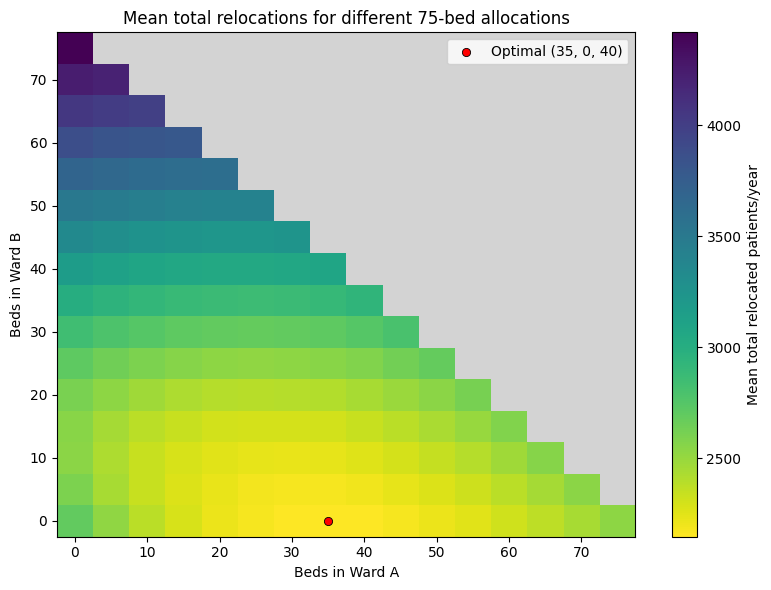

In [ ]:
# Heatmap of mean total relocated patients for the 75-bed grid


step = 5
na_vals = list(range(0, 75 + step, step))
nb_vals = list(range(0, 75 + step, step))

heatmap = (
    grid_75
    .pivot(index="NB", columns="NA", values="mean total relocated")
    .reindex(index=nb_vals, columns=na_vals)
)

# Mask infeasible allocations, i.e. where NA + NB > 75.
# In feasible cells, NC = 75 - NA - NB.
heatmap_values = np.ma.masked_invalid(heatmap.to_numpy(dtype=float))

# Find the optimal allocation from the grid.
best_row = grid_75.iloc[0]
best_NA = int(best_row["NA"])
best_NB = int(best_row["NB"])
best_NC = int(best_row["NC"])

cmap = plt.cm.viridis_r.copy()  # reversed colour scale
cmap.set_bad(color="lightgray")

plt.figure(figsize=(8, 6))
plt.imshow(
    heatmap_values,
    origin="lower",
    aspect="auto",
    extent=[-step / 2, 75 + step / 2, -step / 2, 75 + step / 2],
    cmap=cmap,
)
plt.colorbar(label="Mean total relocated patients/year")

# Small dot at the optimal allocation. This is intentionally not a star.
plt.scatter(
    best_NA,
    best_NB,
    s=35,
    color="red",
    edgecolors="black",
    linewidths=0.6,
    label=f"Optimal ({best_NA}, {best_NB}, {best_NC})",
)

plt.xlabel("Beds in Ward A")
plt.ylabel("Beds in Ward B")
plt.title("Mean total relocations for different 75-bed allocations")
plt.xticks(na_vals[::2])
plt.yticks(nb_vals[::2])
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

In [32]:
best_75 = grid_75.iloc[0]
NA_best, NB_best, NC_best = int(best_75["NA"]), int(best_75["NB"]), int(best_75["NC"])

print("Best allocation found on the grid:")
print(f"NA={NA_best}, NB={NB_best}, NC={NC_best}")
print(f"Mean total relocated/year = {best_75['mean total relocated']:.1f}")


Best allocation found on the grid:
NA=35, NB=0, NC=40
Mean total relocated/year = 2145.4


## 9. Performance of the best setuo



In [33]:
from IPython.display import display

def summarize_optimal_results(results, beds):
    patient_names = ["Type A", "Type B", "Type C"]
    primary_wards = ["Ward A", "Ward B", "Ward C"]
    ward_names = ["Ward A", "Ward B", "Ward C"]

    patient_rows = []
    for i in range(3):
        relocated = [res["relocated"][i] for res in results]
        p_full = [res["prob_full"][i] for res in results]
        p_reloc = [res["prob_relocated"][i] for res in results]

        mean_reloc, lo_reloc, hi_reloc = mean_ci(relocated)
        mean_full, _, _ = mean_ci(p_full)
        mean_preloc, _, _ = mean_ci(p_reloc)

        patient_rows.append({
            "patient_type": patient_names[i],
            "primary ward": primary_wards[i],
            "mean relocated/year": mean_reloc,
            "relocated CI low": lo_reloc,
            "relocated CI high": hi_reloc,
            "P(primary ward full)": mean_full,
            "P(relocated)": mean_preloc,
        })

    total_relocated = [res["total_relocated"] for res in results]
    total_mean, total_lo, total_hi = mean_ci(total_relocated)

    total_pfull = []
    total_preloc = []
    total_util = []
    for res in results:
        arrivals_total = res["arrivals"].sum()
        total_pfull.append(res["full_on_arrival"].sum() / arrivals_total)
        total_preloc.append(res["relocated"].sum() / arrivals_total)
        total_util.append(np.dot(res["utilisation"], beds) / sum(beds))

    patient_rows.append({
        "patient_type": "Total / weighted",
        "primary ward": "All",
        "mean relocated/year": total_mean,
        "relocated CI low": total_lo,
        "relocated CI high": total_hi,
        "P(primary ward full)": mean_ci(total_pfull)[0],
        "P(relocated)": mean_ci(total_preloc)[0],
    })

    util_rows = []
    for i in range(3):
        util = [res["utilisation"][i] for res in results]
        mean_u, lo_u, hi_u = mean_ci(util)
        util_rows.append({
            "ward": ward_names[i],
            "beds": beds[i],
            "mean utilisation": mean_u,
            "utilisation CI low": lo_u,
            "utilisation CI high": hi_u,
        })

    total_mean_u, total_lo_u, total_hi_u = mean_ci(total_util)
    util_rows.append({
        "ward": "Total system",
        "beds": sum(beds),
        "mean utilisation": total_mean_u,
        "utilisation CI low": total_lo_u,
        "utilisation CI high": total_hi_u,
    })

    patient_table = pd.DataFrame(patient_rows)
    utilisation_table = pd.DataFrame(util_rows)

    return patient_table, utilisation_table

optimal_results = run_replications(
    NA_best, NB_best, NC_best,
    n_rep=N_REP,
    los_dist="lognormal",
    seed=BASE_SEED
)

patient_table_opt, utilisation_table_opt = summarize_optimal_results(
    optimal_results,
    beds=(NA_best, NB_best, NC_best)
)


In [34]:
print("Relocated patients table:")
display(patient_table_opt.round(3))

print("\nWard utilisation table:")
display(utilisation_table_opt.round(3))

probability_table = patient_table_opt[
    ["patient_type", "primary ward", "P(primary ward full)", "P(relocated)"]
].copy()

print("\nProbability table:")
display(probability_table.round(3))


Relocated patients table:


,patient_type,primary ward,mean relocated/year,relocated CI low,relocated CI high,P(primary ward full),P(relocated)
0,Type A,Ward A,1150.74,1140.391,1161.089,0.516,0.516
1,Type B,Ward B,229.20,225.396,233.004,1.000,0.514
2,Type C,Ward C,769.15,759.294,779.006,0.351,0.351
3,Total / weighted,All,2149.09,2133.336,2164.844,0.486,0.442



Ward utilisation table:


,ward,beds,mean utilisation,utilisation CI low,utilisation CI high
0,Ward A,35,0.871,0.869,0.872
1,Ward B,0,0.000,0.000,0.000
2,Ward C,40,0.950,0.949,0.950
3,Total system,75,0.913,0.912,0.914



Probability table:


,patient_type,primary ward,P(primary ward full),P(relocated)
0,Type A,Ward A,0.516,0.516
1,Type B,Ward B,1.000,0.514
2,Type C,Ward C,0.351,0.351
3,Total / weighted,All,0.486,0.442


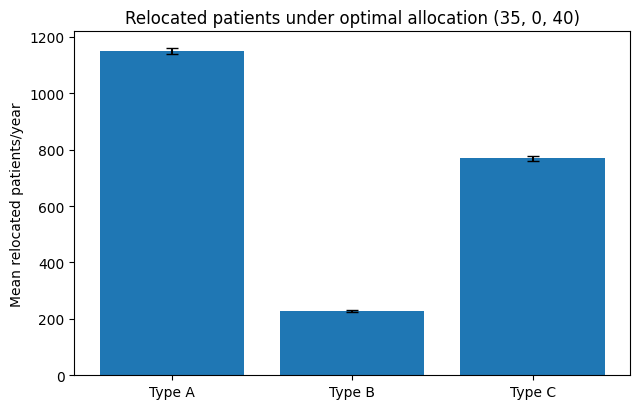

In [35]:
# Bar plot: relocated patients by type under the optimal allocation

plot_df = patient_table_opt.iloc[:3].copy()

plt.figure(figsize=(6.5, 4.2))
plt.bar(
    plot_df["patient_type"],
    plot_df["mean relocated/year"],
    yerr=[
        plot_df["mean relocated/year"] - plot_df["relocated CI low"],
        plot_df["relocated CI high"] - plot_df["mean relocated/year"],
    ],
    capsize=4,
)
plt.ylabel("Mean relocated patients/year")
plt.title(f"Relocated patients under optimal allocation ({NA_best}, {NB_best}, {NC_best})")
plt.tight_layout()
plt.show()


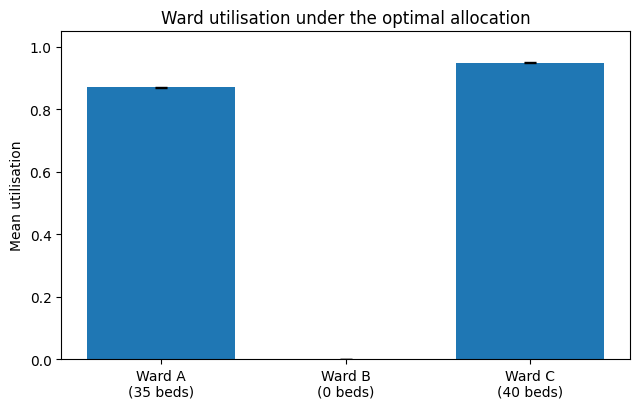

In [36]:
# Bar plot: ward utilisation under the optimal allocation

util_plot_df = utilisation_table_opt.iloc[:3].copy()
labels = [f"{row['ward']}\n({int(row['beds'])} beds)" for _, row in util_plot_df.iterrows()]

plt.figure(figsize=(6.5, 4.2))
plt.bar(
    labels,
    util_plot_df["mean utilisation"],
    yerr=[
        util_plot_df["mean utilisation"] - util_plot_df["utilisation CI low"],
        util_plot_df["utilisation CI high"] - util_plot_df["mean utilisation"],
    ],
    capsize=4,
)
plt.ylim(0, 1.05)
plt.ylabel("Mean utilisation")
plt.title("Ward utilisation under the optimal allocation")
plt.tight_layout()
plt.show()


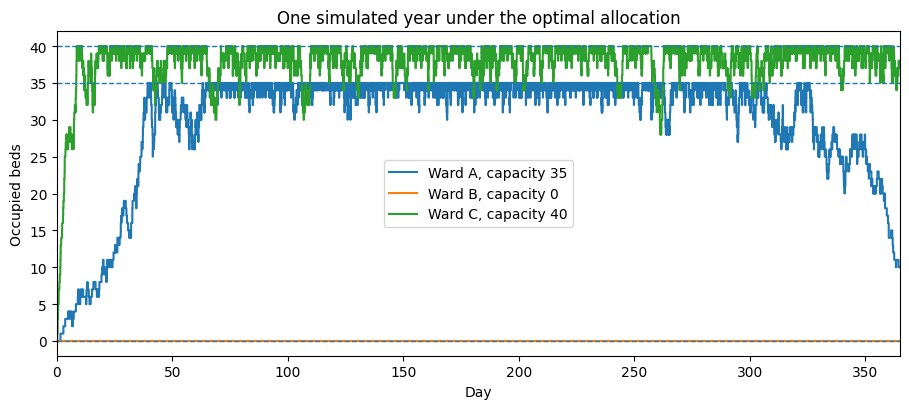

In [42]:
# Plot: one simulated year under the optimal allocation

one_result_opt, trace_opt = simulate_one_year(
    NA_best, NB_best, NC_best,
    los_dist="lognormal",
    seed=BASE_SEED,
    return_trace=True
)

plt.figure(figsize=(9.2, 4.2))
plt.step(trace_opt["time"], trace_opt["occ_A"], where="post", label=f"Ward A, capacity {NA_best}")
plt.step(trace_opt["time"], trace_opt["occ_B"], where="post", label=f"Ward B, capacity {NB_best}")
plt.step(trace_opt["time"], trace_opt["occ_C"], where="post", label=f"Ward C, capacity {NC_best}")
plt.axhline(NA_best, linestyle="--", linewidth=1)
plt.axhline(NB_best, linestyle="--", linewidth=1)
plt.axhline(NC_best, linestyle="--", linewidth=1)
plt.xlabel("Day")
plt.ylabel("Occupied beds")
plt.title("One simulated year under the optimal allocation")
plt.xlim(0, T)
plt.legend()
plt.tight_layout()
plt.show()



## 9. Sensitivity to LOS distribution

We compare the project lognormal LOS with an exponential LOS with the same mean.


In [38]:
log_results = run_replications(
    NA_best, NB_best, NC_best,
    n_rep=N_REP,
    los_dist="lognormal",
    seed=BASE_SEED
)

exp_results = run_replications(
    NA_best, NB_best, NC_best,
    n_rep=N_REP,
    los_dist="exponential",
    seed=BASE_SEED
)

los_rows = []

for name, results in [("Lognormal", log_results), ("Exponential", exp_results)]:
    totals = [res["total_relocated"] for res in results]
    mean, lo, hi = mean_ci(totals)
    util = np.array([res["utilisation"] for res in results]).mean(axis=0)

    los_rows.append({
        "LOS distribution": name,
        "mean total relocated": mean,
        "CI low": lo,
        "CI high": hi,
        "mean util A": util[0],
        "mean util B": util[1],
        "mean util C": util[2],
    })

los_table = pd.DataFrame(los_rows)
los_table


,LOS distribution,mean total relocated,CI low,CI high,mean util A,mean util B,mean util C
0,Lognormal,2149.09,2133.335807,2164.844193,0.870721,0.0,0.949554
1,Exponential,2137.09,2120.748589,2153.431411,0.871695,0.0,0.947800


## 10. Sensitivity to total number of beds

For each total number of beds, we run the same grid-search idea and report the best allocation found.


In [39]:
total_beds_to_test = [60, 65, 70, 75, 80, 90, 100]

total_rows = []

for total_beds in total_beds_to_test:
    grid = grid_search_beds(
        total_beds=total_beds,
        step=5,
        n_rep=30,
        los_dist="lognormal",
        seed=BASE_SEED,
        min_B=0
    )

    best = grid.iloc[0]

    total_rows.append({
        "total beds": total_beds,
        "best NA": int(best["NA"]),
        "best NB": int(best["NB"]),
        "best NC": int(best["NC"]),
        "mean total relocated": best["mean total relocated"],
        "CI low": best["CI low"],
        "CI high": best["CI high"],
    })

total_beds_table = pd.DataFrame(total_rows)
total_beds_table


,total beds,best NA,best NB,best NC,mean total relocated,CI low,CI high
0,60,30,0,30,2637.133333,2612.005705,2662.260962
1,65,30,0,35,2465.100000,2440.295751,2489.904249
2,70,30,0,40,2298.366667,2273.599806,2323.133528
3,75,35,0,40,2138.833333,2114.396796,2163.269870
4,80,40,0,40,1979.366667,1955.261536,2003.471797
5,90,45,0,45,1670.966667,1646.965993,1694.967340
6,100,50,0,50,1381.400000,1356.491960,1406.308040


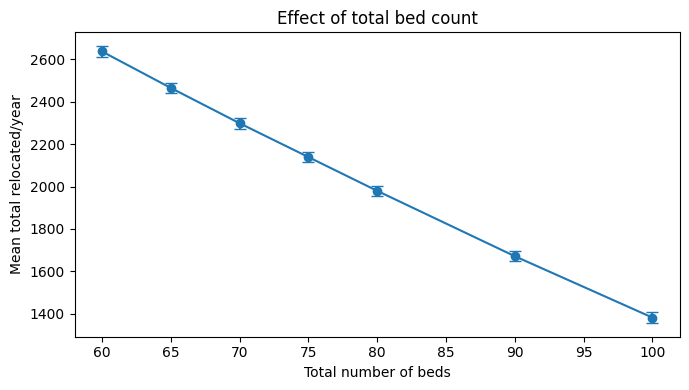

In [40]:
plt.figure(figsize=(7, 4))
plt.errorbar(
    total_beds_table["total beds"],
    total_beds_table["mean total relocated"],
    yerr=[
        total_beds_table["mean total relocated"] - total_beds_table["CI low"],
        total_beds_table["CI high"] - total_beds_table["mean total relocated"]
    ],
    marker="o",
    capsize=4
)
plt.xlabel("Total number of beds")
plt.ylabel("Mean total relocated/year")
plt.title("Effect of total bed count")
plt.tight_layout()
plt.show()
